# MLDoctor - Case3
For an automated social media tagging system designed to predict whether a person appears young in facial images, the developers implemented a model that assigns a probability score to each prediction. To streamline the workflow, a “High-Confidence Bypass” was added: predictions with a probability of 90% or higher were automatically published without human review. During the controlled “Lab Phase,” this approach performed impressively, producing accurate tags with minimal intervention. Since deployment, however, the system has drawn criticism. In practice, it occasionally publishes incorrect tags while still reporting near-certain confidence, leading to unexpected errors despite the apparent reliability suggested by its high probability outputs. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

#import torch which has many of the functions to build deep learning models and to train them
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#import torchvision, which was lots of functions for loading and working with image data
import torchvision
import torchvision.transforms as transforms

#this is a nice progress bar representation that will be good to measure progress during training
import tqdm
import copy
import random

# fix seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# setup device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') #this line checks if we have a GPU available
print(f"Using device: {device}")

Using device: cuda:0


## Data

In [3]:
# Load the full training dataset first (without transforms for now)
test_internal_dataset = torchvision.datasets.ImageFolder('Case3Dataset/test_internal')
print(f'Validation dataset size: {len(test_internal_dataset)}')
test_external_dataset = torchvision.datasets.ImageFolder('Case3Dataset/test_external')
print(f'Test external dataset size: {len(test_external_dataset)}')

# Imnagenet preprocessing
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds = (0.229, 0.224, 0.225)

# preprocessing transform
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Resize((224, 224)), 
    transforms.Normalize(imagenet_means, imagenet_stds)])


# Apply transforms to the datasets
test_internal_dataset.transform = transform
test_external_dataset.transform = transform

# create dataloaders for train, val, test datasets
batch_size = 16
test_internal_loader = torch.utils.data.DataLoader(test_internal_dataset, batch_size=batch_size, shuffle=False, num_workers = 1)
test_external_loader = torch.utils.data.DataLoader(test_external_dataset, batch_size=batch_size, shuffle=False, num_workers = 1)

Validation dataset size: 300
Test external dataset size: 300


## Developed Model

In [4]:
def setup_model(model, num_classes, freeze_backbone = False):
    
    #### Adapt the architecture for the new number of classes.
    in_features = model.fc.in_features
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    #### If necessary, freeze any weights.
    if freeze_backbone: 
        for param in model.parameters():
            param.requires_grad = False
        
        # Unfreeze the parameters of the last fully connected layer
        for param in model.fc.parameters():
            param.requires_grad = True

    return model

# setup the model
backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet_frozen = setup_model(backbone, 2, False)

# Load the developed model
resnet_frozen.load_state_dict(torch.load("resnet_frozen_best_case3.pth"))
resnet_frozen.eval()
resnet_frozen = resnet_frozen.to(device)
print(resnet_frozen)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Evaluation

In [5]:
# Load the best model
resnet_frozen.eval()

# Collect predictions and ground truth labels
all_predictions = {'internal': [], 'external': []}
all_labels = {'internal': [], 'external': []}

# compute predictions
with torch.no_grad():
    for split, dataloader in zip(['internal', 'external'], [test_internal_loader, test_external_loader]):
        for data in tqdm.tqdm(dataloader, desc=f'Evaluating on {split} set'):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = resnet_frozen(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_predictions[split].append(probs.cpu().numpy())
            all_labels[split].append(labels.cpu().numpy())
print("Evaluation complete.")

for split in ['internal', 'external']:
    all_predictions[split] = np.concatenate(all_predictions[split], axis=0)
    all_labels[split] = np.concatenate(all_labels[split], axis=0)
    predicted_classes = np.argmax(all_predictions[split], axis=1)
    accuracy = (predicted_classes == all_labels[split]).mean()
    print(f"{split} set - Accuracy: {accuracy:.3f}")

Evaluating on external set: 100%|██████████| 19/19 [00:01<00:00, 16.35it/s]

Evaluation complete.
internal set - Accuracy: 0.973
external set - Accuracy: 0.593


Class mapping: {'negative': 0, 'positive': 1}


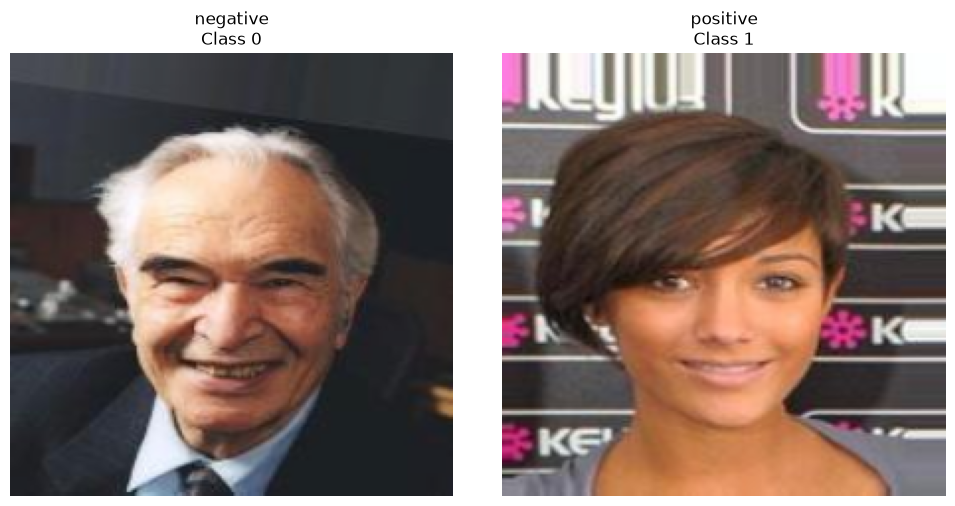

In [6]:
# Check class names and corresponding indices
print("Class mapping:",test_internal_dataset.class_to_idx)

# Display one sample image from each class
fig,axes=plt.subplots(1,len(test_internal_dataset.classes),figsize=(10,5))

for class_idx,class_name in enumerate(test_internal_dataset.classes):
    # Find the first sample belonging to this class
    sample_idx=test_internal_dataset.targets.index(class_idx)
    image,label=test_internal_dataset[sample_idx]

    # Reverse ImageNet normalization for visualization
    image=image.cpu().numpy().transpose(1,2,0)
    image=image*np.array(imagenet_stds)+np.array(imagenet_means)
    image=np.clip(image,0,1)

    axes[class_idx].imshow(image)
    axes[class_idx].set_title(f"{class_name}\nClass {class_idx}")
    axes[class_idx].axis("off")

plt.tight_layout()
plt.show()


===== INTERNAL SET =====
Accuracy : 0.973
Precision: 0.973
Recall   : 0.973
F1-score : 0.973


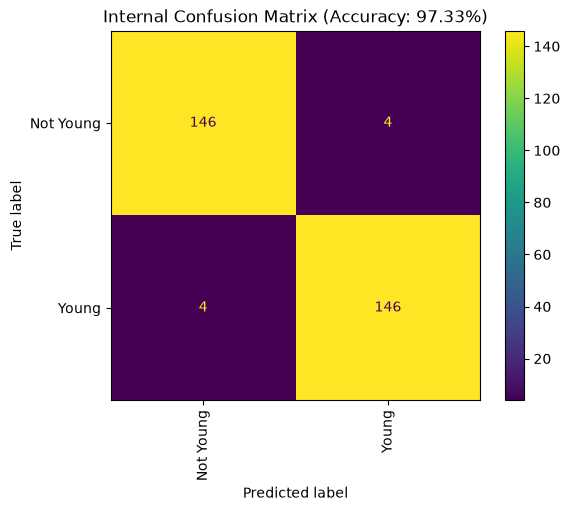


===== EXTERNAL SET =====
Accuracy : 0.593
Precision: 0.561
Recall   : 0.853
F1-score : 0.677


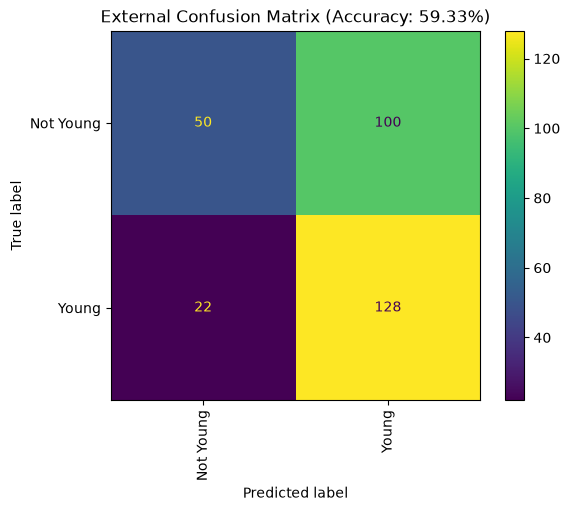

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

# Compute TP, FP, TN, FN for binary classification
def confusion_matrix_counts(labels,probs,threshold=0.5):
    labels=labels.astype(bool)
    probs=probs.astype(float)

    # Convert probabilities to binary predictions
    preds=probs>=threshold

    tp=np.sum(preds&labels)
    fp=np.sum(preds&~labels)
    tn=np.sum(~preds&~labels)
    fn=np.sum(~preds&labels)

    return tp,fp,tn,fn


# Compute precision, recall and F1-score
def compute_metrics(labels,probs,threshold=0.5):
    tp,fp,tn,fn=confusion_matrix_counts(labels,probs,threshold=threshold)

    precision=tp/(tp+fp) if (tp+fp)>0 else 0
    recall=tp/(tp+fn) if (tp+fn)>0 else 0
    f1=2*precision*recall/(precision+recall) if (precision+recall)>0 else 0

    return precision,recall,f1


# Evaluate the model on the internal and external test sets
threshold=0.5

for split in ['internal','external']:

    # Ground-truth labels: 0 = Not Young, 1 = Young
    labels=all_labels[split]

    # Predicted probability for Young
    probs_young=all_predictions[split][:,1]

    # Convert probabilities to predicted classes
    preds=probs_young>=threshold

    # Compute evaluation metrics
    accuracy=(preds==labels.astype(bool)).mean()
    precision,recall,f1=compute_metrics(labels,probs_young,threshold=threshold)

    # Print results
    print(f"\n===== {split.upper()} SET =====")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")

    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(labels,preds,display_labels=['Not Young','Young'],xticks_rotation='vertical')

    plt.title(f'{split.capitalize()} Confusion Matrix (Accuracy: {accuracy*100:.2f}%)')
    plt.show()

The external test accuracy decreased to 59.3%.   
The confusion matrix showed that false positives were the dominant error, with 100 Not Young samples incorrectly classified as Young, compared with 22 false negatives.

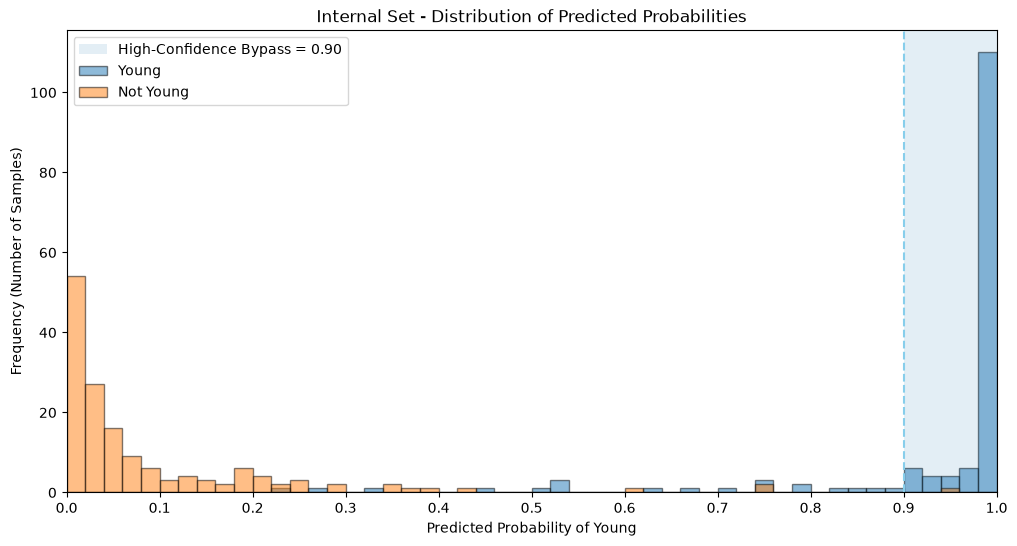

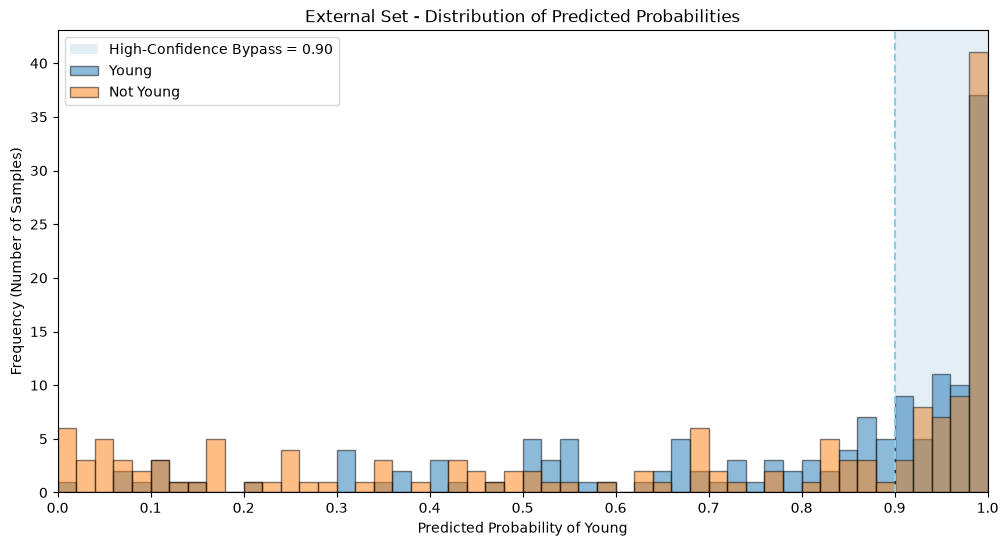

In [21]:
# Plot predicted probability distributions for Internal and External sets
num_bins=50
confidence_threshold=0.9

for split in ['internal','external']:

    # Ground-truth labels: 0 = Not Young, 1 = Young
    labels=all_labels[split].astype(bool)

    # Predicted probability for Young
    probs_young=all_predictions[split][:,1]

    # Separate probabilities by actual class
    young_counts,young_bin_edges=np.histogram(probs_young[labels],bins=num_bins,range=(0,1))
    not_young_counts,not_young_bin_edges=np.histogram(probs_young[~labels],bins=num_bins,range=(0,1))

    # Plot histogram
    plt.figure(figsize=(12,6))
    plt.bar(young_bin_edges[:-1],young_counts,width=young_bin_edges[1]-young_bin_edges[0],edgecolor='black',align='edge',label='Young',alpha=0.5)
    plt.bar(not_young_bin_edges[:-1],not_young_counts,width=not_young_bin_edges[1]-not_young_bin_edges[0],edgecolor='black',align='edge',label='Not Young',alpha=0.5)

    # High-Confidence Bypass
    plt.axvspan(confidence_threshold,1,alpha=0.12,label='High-Confidence Bypass = 0.90')
    plt.axvline(x=confidence_threshold,color='skyblue',linestyle='--',linewidth=1.5)

    plt.xlabel('Predicted Probability of Young')
    plt.ylabel('Frequency (Number of Samples)')
    plt.title(f'{split.capitalize()} Set - Distribution of Predicted Probabilities')
    plt.xticks(np.linspace(0,1,11))
    plt.xlim(0,1)
    plt.legend()
    plt.show()

The predicted probability distributions showed clear separation between the Young and Not Young classes on the internal set. In contrast, the external set contained a substantial number of Not Young samples assigned probabilities above 90% for the Young class, indicating highly confident incorrect predictions.

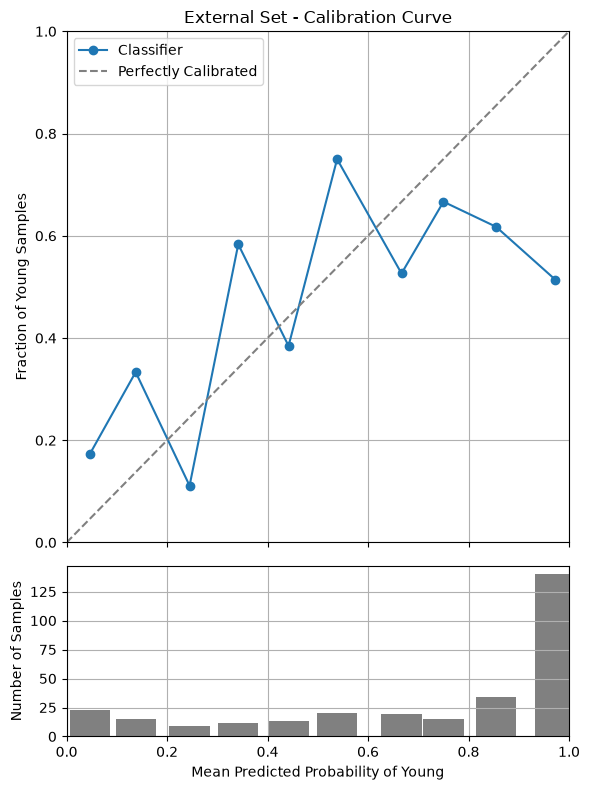

In [22]:
# Number of bins
n_bins=10
bins=np.linspace(0,1,n_bins+1)

# Ground-truth labels: 0 = Not Young, 1 = Young
labels=all_labels['external'].astype(bool)

# Predicted probability for Young
probs_young=all_predictions['external'][:,1]

# Assign each prediction to a probability bin
bin_indices=np.digitize(probs_young,bins)-1
bin_indices=np.clip(bin_indices,0,n_bins-1)

bin_true_frac=[]
bin_mean_prob=[]
bin_counts=[]

for i in range(n_bins):
    mask=bin_indices==i
    mask_sum=np.sum(mask)
    bin_counts.append(mask_sum)

    if mask_sum>0:
        bin_true_frac.append(np.mean(labels[mask]))
        bin_mean_prob.append(np.mean(probs_young[mask]))
    else:
        bin_true_frac.append(np.nan)
        bin_mean_prob.append(np.nan)

bin_true_frac=np.array(bin_true_frac)
bin_mean_prob=np.array(bin_mean_prob)
bin_counts=np.array(bin_counts)

# Create calibration curve and sample distribution
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(6,8),sharex=True,gridspec_kw={'height_ratios':[3,1]})

# Top: Calibration curve
ax1.plot(bin_mean_prob,bin_true_frac,marker='o',label='Classifier')
ax1.plot([0,1],[0,1],linestyle='--',color='gray',label='Perfectly Calibrated')
ax1.set_ylabel('Fraction of Young Samples')
ax1.set_title('External Set - Calibration Curve')
ax1.set_xlim(0,1)
ax1.set_ylim(0,1)
ax1.grid(True)
ax1.legend()

# Bottom: Sample distribution
ax2.bar(bin_mean_prob,bin_counts,width=0.08,color='gray')
ax2.set_xlabel('Mean Predicted Probability of Young')
ax2.set_ylabel('Number of Samples')
ax2.set_xlim(0,1)
ax2.grid(True)

plt.tight_layout()
plt.show()

The calibration analysis on the external set showed fluctuations around the perfectly calibrated line, indicating inconsistent alignment between predicted probabilities and the observed fraction of Young samples. In particular, pronounced overconfidence was observed in the High-Confidence Bypass region above 90%, where the calibration curve fell substantially below the perfectly calibrated line. This indicates that high-confidence predictions became unreliable after deployment.

In [20]:
# External probabilities and labels
labels=all_labels['external']
probs_young=all_predictions['external'][:,1]

# High-Confidence Bypass: P(Young) >= 0.90
high_conf_mask=probs_young>=0.9

# Samples automatically published as Young
high_conf_probs=probs_young[high_conf_mask]
high_conf_labels=labels[high_conf_mask]

# Count correct and incorrect high-confidence predictions
high_conf_total=len(high_conf_labels)
high_conf_correct=np.sum(high_conf_labels==1)
high_conf_incorrect=np.sum(high_conf_labels==0)
high_conf_accuracy=high_conf_correct/high_conf_total if high_conf_total>0 else 0

print("===== EXTERNAL HIGH-CONFIDENCE BYPASS =====")
print(f"Total bypassed predictions : {high_conf_total}")
print(f"Correct Young predictions  : {high_conf_correct}")
print(f"Incorrect Not Young samples: {high_conf_incorrect}")
print(f"Bypass accuracy            : {high_conf_accuracy:.3f}")

===== EXTERNAL HIGH-CONFIDENCE BYPASS =====
Total bypassed predictions : 140
Correct Young predictions  : 72
Incorrect Not Young samples: 68
Bypass accuracy            : 0.514


Among the 140 external predictions that entered the High-Confidence Bypass, only 72 were actually Young, resulting in a bypass accuracy of 51.4%.   
The remaining 68 Not Young samples would therefore have been incorrectly tagged as Young and automatically published without human review.

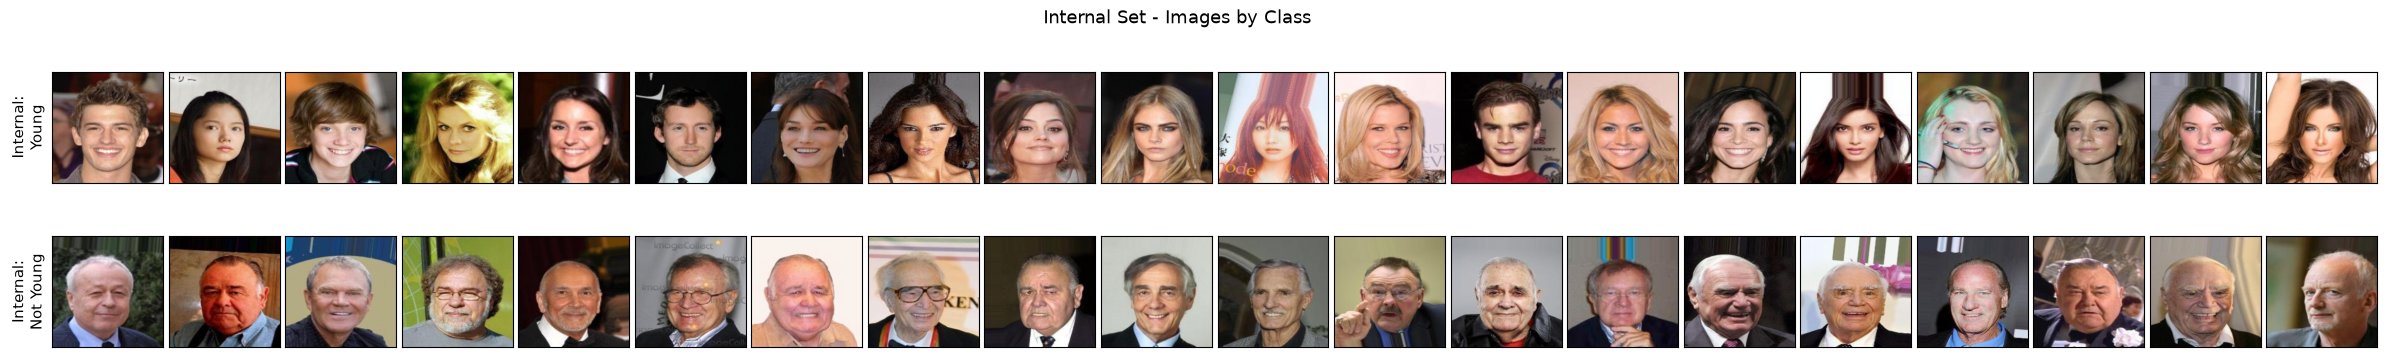

In [35]:
# Select 20 samples from each class for Internal set
np.random.seed(0)

internal_labels=all_labels['internal']

internal_young=np.where(internal_labels==1)[0]
internal_not_young=np.where(internal_labels==0)[0]

selected_internal_young=np.random.choice(internal_young,20,replace=False)
selected_internal_not_young=np.random.choice(internal_not_young,20,replace=False)

# Denormalize images for visualization
def denormalize_image(image):
    image=image.numpy().transpose(1,2,0)
    image=image*np.array(imagenet_stds)+np.array(imagenet_means)
    return np.clip(image,0,1)

# Create figure
fig,axes=plt.subplots(2,20,figsize=(30,4))

# Internal - Young
for col,idx in enumerate(selected_internal_young):
    image,label=test_internal_dataset[idx]
    axes[0,col].imshow(denormalize_image(image))
    axes[0,col].set_xticks([])
    axes[0,col].set_yticks([])

# Internal - Not Young
for col,idx in enumerate(selected_internal_not_young):
    image,label=test_internal_dataset[idx]
    axes[1,col].imshow(denormalize_image(image))
    axes[1,col].set_xticks([])
    axes[1,col].set_yticks([])

# Labels
axes[0,0].set_ylabel('Internal:\nYoung',fontsize=11)
axes[1,0].set_ylabel('Internal:\nNot Young',fontsize=11)

plt.suptitle('Internal Set - Images by Class',fontsize=13)

plt.subplots_adjust(
    hspace=0.25,
    wspace=0.05,
    top=0.85
)

plt.show()

Visual inspection of the internal dataset suggests a strong association between the target labels and appearance-related characteristics. The Not Young class predominantly consists of older male-presenting individuals, with many images showing limited hair and exposed foreheads, whereas the Young class includes both female-presenting and younger male-presenting individuals.

High-confidence Young samples: 72
High-confidence Not Young samples: 68
Low-probability Young samples: 22
Low-probability Not Young samples: 50


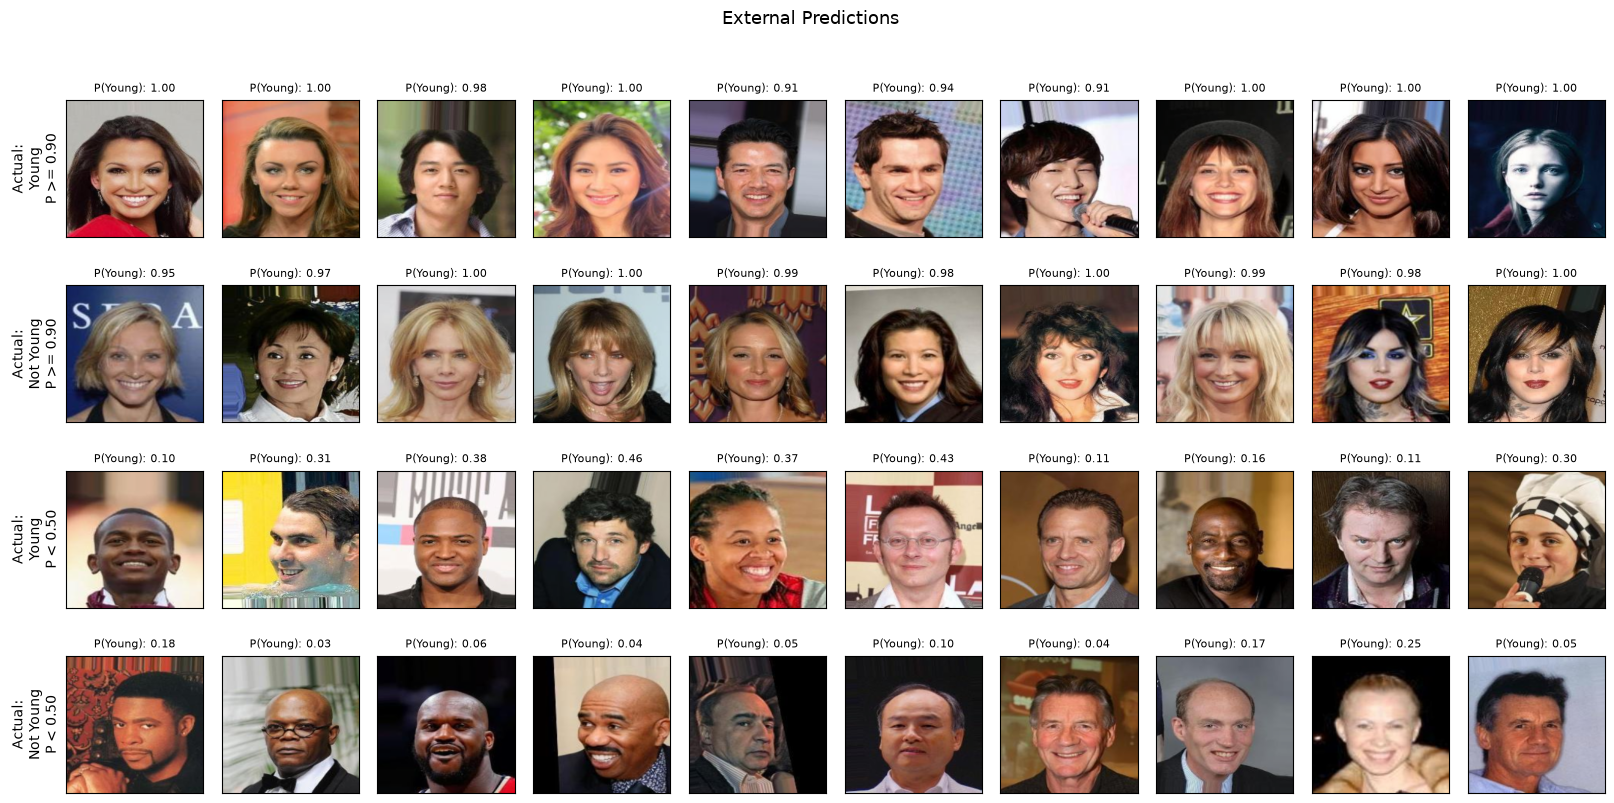

In [36]:
# Get external labels and predicted probabilities
labels=all_labels['external']
probs_young=all_predictions['external'][:,1]

# Identify samples
high_conf_young=np.where((labels==1)&(probs_young>=0.9))[0]
high_conf_not_young=np.where((labels==0)&(probs_young>=0.9))[0]

low_prob_young=np.where((labels==1)&(probs_young<0.5))[0]
low_prob_not_young=np.where((labels==0)&(probs_young<0.5))[0]

print(f'High-confidence Young samples: {len(high_conf_young)}')
print(f'High-confidence Not Young samples: {len(high_conf_not_young)}')
print(f'Low-probability Young samples: {len(low_prob_young)}')
print(f'Low-probability Not Young samples: {len(low_prob_not_young)}')

# Select 10 samples from each group
np.random.seed(0)

selected_young=np.random.choice(high_conf_young,10,replace=False)
selected_not_young=np.random.choice(high_conf_not_young,10,replace=False)

selected_low_young=np.random.choice(low_prob_young,10,replace=False)
selected_low_not_young=np.random.choice(low_prob_not_young,10,replace=False)

# Denormalize images for visualization
def denormalize_image(image):
    image=image.numpy().transpose(1,2,0)
    image=image*np.array(imagenet_stds)+np.array(imagenet_means)
    return np.clip(image,0,1)

# Create figure
fig,axes=plt.subplots(4,10,figsize=(20,9))

# High-confidence actual Young
for col,idx in enumerate(selected_young):
    image,label=test_external_dataset[idx]
    axes[0,col].imshow(denormalize_image(image))
    axes[0,col].set_title(f'P(Young): {probs_young[idx]:.2f}',fontsize=8)
    axes[0,col].set_xticks([])
    axes[0,col].set_yticks([])

# High-confidence actual Not Young
for col,idx in enumerate(selected_not_young):
    image,label=test_external_dataset[idx]
    axes[1,col].imshow(denormalize_image(image))
    axes[1,col].set_title(f'P(Young): {probs_young[idx]:.2f}',fontsize=8)
    axes[1,col].set_xticks([])
    axes[1,col].set_yticks([])

# Low-probability actual Young
for col,idx in enumerate(selected_low_young):
    image,label=test_external_dataset[idx]
    axes[2,col].imshow(denormalize_image(image))
    axes[2,col].set_title(f'P(Young): {probs_young[idx]:.2f}',fontsize=8)
    axes[2,col].set_xticks([])
    axes[2,col].set_yticks([])

# Low-probability actual Not Young
for col,idx in enumerate(selected_low_not_young):
    image,label=test_external_dataset[idx]
    axes[3,col].imshow(denormalize_image(image))
    axes[3,col].set_title(f'P(Young): {probs_young[idx]:.2f}',fontsize=8)
    axes[3,col].set_xticks([])
    axes[3,col].set_yticks([])

# Labels
axes[0,0].set_ylabel('Actual:\nYoung\nP >= 0.90',fontsize=10)
axes[1,0].set_ylabel('Actual:\nNot Young\nP >= 0.90',fontsize=10)
axes[2,0].set_ylabel('Actual:\nYoung\nP < 0.50',fontsize=10)
axes[3,0].set_ylabel('Actual:\nNot Young\nP < 0.50',fontsize=10)

plt.suptitle('External Predictions',fontsize=13)
plt.subplots_adjust(hspace=0.35,wspace=0.05,top=0.88)
plt.show()

Visual inspection of the external high-confidence predictions further showed that most female-presenting Not Young samples were incorrectly assigned high probabilities above 90% for the Young class, while female-presenting samples with more exposed foreheads and limited hair coverage were instead assigned probabilities below 0.50 for the Young class, suggesting that the model may have relied on demographic and appearance-related features rather than robust age-related facial characteristics.

>**Diagnosis:** The model appears to have learned an association between gender-associated and appearance-related characteristics and the Young label. In the internal dataset, Not Young samples were predominantly older male-presenting individuals with limited hair and exposed foreheads, while the Young class included female-presenting and younger male-presenting individuals. During deployment, this association became unreliable, as many female-presenting Not Young samples in the external dataset were incorrectly assigned probabilities above 90% for Young. This suggests that the model may have relied on these learned appearance patterns rather than consistently identifying robust age-related facial characteristics.
    
> **Evidence:** Accuracy decreased substantially from 97.3% on the internal test set to 59.3% on the external test set. On the external set, the confusion matrix showed 100 false positives, where Not Young samples were incorrectly classified as Young, and 22 false negatives, where Young samples were incorrectly classified as Not Young. The external probability distribution showed substantially greater concentration of predictions at high confidence, while the calibration analysis showed pronounced overconfidence in the high-probability region. Among the external predictions with probabilities of 90% or higher, 140 samples entered the High-Confidence Bypass, of which only 72 were actually Young and 68 were Not Young, resulting in a bypass accuracy of 51.4%. Visual inspection of the internal dataset suggested a strong association between the target labels and appearance-related characteristics. The Not Young class predominantly consisted of older male-presenting individuals, with many images showing limited hair and exposed foreheads, whereas the Young class included both female-presenting and younger male-presenting individuals. Visual inspection of the external high-confidence predictions further showed that many female-presenting Not Young samples were incorrectly assigned high probabilities above 90% for the Young class, while female-presenting samples with more exposed foreheads and limited hair coverage were instead assigned probabilities below 0.50 for the Young class, suggesting that the model may have relied on demographic and appearance-related features rather than robust age-related facial characteristics.
    
> **Recommendation:** The training and validation datasets should include more diverse gender-associated appearances across both the Young and Not Young classes, so that the model is exposed to a wider range of appearances within each class. In particular, female-presenting individuals should be adequately represented in the Not Young class, while male-presenting individuals should also be represented in the Young class. This may reduce the model's reliance on the appearance patterns observed in the internal dataset. In addition, the 90% High-Confidence Bypass should be re-evaluated using a representative validation set that reflects the expected deployment data, and calibration should be assessed before allowing high-confidence predictions to be automatically published without human review.